# Fully Connected Neural Network for MNIST — From Scratch (NumPy) and in PyTorch

In this assignment we build the **same** network twice:
- **Part A**: NumPy from scratch (we compute the gradients by hand — no gradient library)
- **Part B**: PyTorch (exact same architecture)

**Required architecture:** `layer_dims = [784, 128, 64, 10]`


> MNIST: one image is 28x28 = 784 features, and there are 10 digit classes (0..9).

## 1) Imports and setup


In [2]:
import time
import warnings
import numpy as np

try:
    import torch
    import torch.nn as nn
    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False

try:
    from torchvision import datasets, transforms
    HAVE_TORCHVISION = True
except ImportError:
    HAVE_TORCHVISION = False
    from sklearn.datasets import fetch_openml

try:
    import matplotlib.pyplot as plt
    HAVE_MATPLOTLIB = True
except ImportError:
    HAVE_MATPLOTLIB = False

warnings.filterwarnings("ignore")
print("torch:", HAVE_TORCH, "| torchvision:", HAVE_TORCHVISION, "| matplotlib:", HAVE_MATPLOTLIB)

torch: True | torchvision: False | matplotlib: True


## 2) Loading MNIST + preprocessing

**What we do:** read the 70,000 handwritten digit images and prepare them for our network.

**Steps:**
1. flatten each 28x28 image into 784 features,
2. divide by 255 (normalise) so values are in `[0, 1]` (easier to train),
3. for **NumPy**: examples are **columns** `X.shape = (784, m)`, labels are **one-hot** `Y.shape = (10, m)`,
4. for **PyTorch**: examples are **rows** `(m, 784)`, labels are **integer class indices** (0..9).

**One-hot example:** the digit `3` becomes the column `[0,0,0,1,0,0,0,0,0,0]`.

In [3]:
def load_mnist():
    """Returns X_train, y_train, X_test, y_test (each image flattened to 784)."""
    if HAVE_TORCHVISION:
        transform = transforms.Compose([transforms.ToTensor()])
        train_set = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
        test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
        X_train = train_set.data.numpy().reshape(-1, 784) / 255.0
        y_train = train_set.targets.numpy()
        X_test  = test_set.data.numpy().reshape(-1, 784) / 255.0
        y_test  = test_set.targets.numpy()
        return X_train, y_train, X_test, y_test

    # Fallback: sklearn's copy of the same MNIST data.
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X = mnist.data / 255.0
    y = mnist.target.astype(int)
    return X[:60000], y[:60000], X[60000:], y[60000:]


def one_hot(labels, num_classes=10):
    """Convert integer labels (m,) into a one-hot matrix (10, m)."""
    m = labels.shape[0]
    Y = np.zeros((num_classes, m))
    for i in range(m):
        Y[labels[i], i] = 1.0
    return Y

In [4]:
# Prepare the raw data in the NumPy style: columns + one-hot + float64.
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_mnist()

X_train = X_train_raw.T.astype(np.float64)                  # (784, 60000)
Y_train = one_hot(y_train_raw.astype(int)).astype(np.float64)  # (10, 60000)
X_test  = X_test_raw.T.astype(np.float64)
Y_test  = one_hot(y_test_raw.astype(int)).astype(np.float64)

print("X_train:", X_train.shape, " (features, examples)")
print("Y_train:", Y_train.shape, " (classes, examples)")

X_train: (784, 60000)  (features, examples)
Y_train: (10, 60000)  (classes, examples)


## 3) `initialize_parameters` — He initialization

**What:** create a weight matrix `W` and a bias vector `b` for **every** layer.
**Why:** we cannot make predictions without starting weights, and how we fill them decides whether training works.

**Formula:**
\[
W[l] = \text{randn}(n_l,\, n_{prev}) \times \sqrt{\frac{2}{n_{prev}}}, \qquad b[l] = 0
\]
`randn` gives random numbers with mean 0 and std 1. Multiplying by `sqrt(2/n_prev)` keeps the
signal roughly constant as we go deeper (no vanishing / exploding) and makes all neurons learn
different things (identical weights would all learn the same).

**Shapes** for `[784, 128, 64, 10]`:
- `W1 (128, 784)` with `b1 (128, 1)`
- `W2 (64, 128)`  with `b2 (64, 1)`
- `W3 (10, 64)`   with `b3 (10, 1)`

In [5]:
def initialize_parameters(layer_dims, seed=0):
    """
    layer_dims: list of neuron counts, e.g. [784, 128, 64, 10].
    Returns   : dict like {"W1":..., "b1":..., "W2":..., ...}
    """
    np.random.seed(seed)
    parameters = {}
    L = len(layer_dims) - 1                   # how many layers to create
    for l in range(1, L + 1):
        n_prev = layer_dims[l - 1]            # neurons coming in
        n_l    = layer_dims[l]                # neurons going out
        W = np.random.randn(n_l, n_prev) * np.sqrt(2.0 / n_prev)   # He init
        b = np.zeros((n_l, 1))
        parameters["W" + str(l)] = W
        parameters["b" + str(l)] = b
    return parameters

## 4) Activations — ReLU, ReLU derivative, Softmax

**What:** three small helpers used in the forward and backward passes.
**Why:** an activation adds non-linearity. Without it the network becomes one big
linear function and could never separate 10 digits, no matter how many layers it has.

- **ReLU:** `max(0, Z)` — keeps positives, zeros negatives
- **ReLU derivative:** `1` where `Z > 0`, else `0` — this is what backward multiplies by
- **Softmax:** turns the last layer's raw scores into probabilities (each column sums to 1)

**Numerical trick:** subtract the maximum value **before** `np.exp()`:
\[
\text{softmax}(Z_i)=\frac{e^{Z_i - \max(Z)}}{\sum_j e^{Z_j - \max(Z)}}
\]
Subtracting a constant changes nothing mathematically (it cancels in the fraction) but
protects against `exp(1000) = inf`.

In [6]:
def relu(Z):
    """ReLU: returns max(0, Z)."""
    return np.maximum(0, Z)


def relu_derivative(Z):
    """Derivative of ReLU: 1 where Z > 0, else 0. Same shape as Z."""
    return (Z > 0).astype(float)


def softmax(Z):
    """
    Numerically stable softmax.
    Z shape (n, m)  ->  returns A shape (n, m), every column sums to 1.
    """
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)   # prevents overflow
    exp_Z = np.exp(Z_shifted)
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    return A

## 5) `layer_forward` — one step forward for one layer

**Formula:**
\[
Z = W \;@\; A_{prev} + b, \qquad A = \text{activation}(Z)
\]
- hidden layers use **ReLU**
- the last layer uses **Softmax**

**Why we return both `Z` and `A`:** backward needs `Z` to compute the activation's
derivative exactly at that point.

**Shapes:** `W (n_l, n_prev)`, `A_prev (n_prev, m)`, `Z and A (n_l, m)`.
The bias `b` is added to all `m` columns at once via broadcasting.

In [7]:
def layer_forward(A_prev, W, b, activation):
    """
    A_prev (n_prev, m)  W (n_l, n_prev)  b (n_l, 1)
    activation: "relu" for hidden layers, "softmax" for the last layer
    Returns   : A (n_l, m)  and  Z (n_l, m)
    """
    Z = np.matmul(W, A_prev) + b
    if activation == "relu":
        A = relu(Z)
    elif activation == "softmax":
        A = softmax(Z)
    else:
        raise ValueError("Unknown activation: " + str(activation))
    return A, Z

## 6) `model_forward` — the whole network

**What:** pass the input through **all** layers.
**Why a loop?** to support any `layer_dims` without hardcoding a number of layers.

**What we save:** `(A_prev, Z, W, b)` for each layer in `caches`.
`A_prev` is the **input** of that layer — backward needs it to build `dW = (1/m) dZ @ A_prev.T`.

**Shapes:** input `(784, m)`; after hidden layers activations are `(128, m)` then `(64, m)`;
final output `AL` is `(10, m)`.

In [8]:
def model_forward(X, parameters):
    """
    X (784, m)  parameters from initialize_parameters
    Returns : AL (10, m)  and  caches = list of (A_prev, Z, W, b) per layer
    """
    caches = []
    L = len(parameters) // 2                  # W and b per layer -> divide by 2

    A = X
    for l in range(1, L):
        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]
        A_prev = A
        A, Z = layer_forward(A_prev, W, b, "relu")      # hidden layers
        caches.append((A_prev, Z, W, b))

    W = parameters["W" + str(L)]
    b = parameters["b" + str(L)]
    A_prev = A
    AL, Z = layer_forward(A_prev, W, b, "softmax")      # last layer
    caches.append((A_prev, Z, W, b))
    return AL, caches

## 7) `compute_cost` — categorical cross-entropy

**What:** a single number telling us how wrong the predictions are.

**Formula:**
\[
\text{Cost} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{c=1}^{10} Y_{c,i} \; \ln(AL_{c,i})
\]
Because `Y` is one-hot, only the term of the **correct class** survives — the cost equals
`-ln(probability of the correct digit)`.

**Why we clip:** `log(0) = -inf`. Clipping to `[1e-12, 1-1e-12]` keeps the maths safe.

The perfect network predicts 1.0 for the right class every time -> cost 0.

In [9]:
def compute_cost(AL, Y):
    """AL (10, m)  Y (10, m). Returns the mean cross-entropy."""
    m = Y.shape[1]
    eps = 1e-12
    AL_clipped = np.clip(AL, eps, 1.0 - eps)      # prevent log(0)
    cost_matrix = -Y * np.log(AL_clipped)         # only the true class matters
    return np.sum(cost_matrix) / m

## 8) `layer_backward` — one step backward (the most important part)

**What:** compute the gradients for one hidden (ReLU) layer, given the gradient coming from above.

Each formula is just the **chain rule**:

**1) Pass the gradient through the activation:**
\[
dZ = dA \;\cdot\; \text{ReLU}'(Z)
\]
`dA` tells how much the output contributed to the error; `relu'(Z)` (0 or 1) tells how
much `Z` contributed to that output.

**2) Gradient of the weights:**
\[
dW = \frac{1}{m}\, dZ \;@\; A_{prev}^{T}
\]
- `dZ` tells us how much the output contributed to the error,
- `A_prev` is the input that entered the layer,
- their multiplication gives the effect of **each weight** on the error,
- `1/m` averages the gradient over the mini-batch,
- `A_prev.T` is needed purely to match the **matrix dimensions**:
  `(n_l, m) @ (m, n_prev) -> (n_l, n_prev)`.

**3) Gradient of the bias:**
\[
db = \frac{1}{m} \sum_{\text{examples}} dZ \qquad (n_l, 1)
\]

**4) What we pass to the previous layer:**
\[
dA_{prev} = W^{T} \;@\; dZ
\]
`W.T` has shape `(n_prev, n_l)`, routing the error back to where the previous activations came from.

In [10]:
def layer_backward(dA, Z, A_prev, W, activation):
    """
    dA (n_l, m)  Z (n_l, m)  A_prev (n_prev, m)  W (n_l, n_prev)
    Returns: dA_prev (n_prev, m)  dW (n_l, n_prev)  db (n_l, 1)
    """
    m = A_prev.shape[1]
    if activation == "relu":
        dZ = dA * relu_derivative(Z)     # chain rule
    else:
        raise ValueError("layer_backward only used for ReLU layers here.")

    dW = (1.0 / m) * np.matmul(dZ, A_prev.T)
    db = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.matmul(W.T, dZ)
    return dA_prev, dW, db

## 9) `model_backward` — backpropagation for the whole network

**The famous shortcut for the last layer:** we used **Softmax** at the output and
**Cross-Entropy** as the cost. Combining their derivatives with the chain rule produces a
beautifully simple result:
\[
dZ[L] = AL - Y \qquad (\text{output minus target})
\]
We do **not** need to work out `d(cost)/dA * d(softmax)/dZ` by hand!
`CrossEntropyLoss` in PyTorch uses the exact same simplification internally.

Then we compute `dW`, `db`, and walk **backwards** through the hidden layers with
`layer_backward`, reusing the values saved in `caches` during the forward pass.

In [11]:
def model_backward(AL, Y, caches):
    """
    AL (10, m)  Y (10, m)  caches from model_forward
    Returns: grads = {"dW1":..., "db1":..., "dW2":..., ...}
    """
    grads = {}
    L = len(caches)

    # ---------- last layer: simplified gradient dZ[L] = AL - Y ----------
    A_prev_L, Z_L, W_L, b_L = caches[L - 1]
    dZ_L = AL - Y
    m = Y.shape[1]

    dW_L = (1.0 / m) * np.matmul(dZ_L, A_prev_L.T)
    db_L = (1.0 / m) * np.sum(dZ_L, axis=1, keepdims=True)
    dA_prev = np.matmul(W_L.T, dZ_L)

    grads["dW" + str(L)] = dW_L
    grads["db" + str(L)] = db_L

    # ---------- hidden layers, visited backwards: L-1, L-2, ..., 1 ----------
    for l in reversed(range(1, L)):
        A_prev_l, Z_l, W_l, b_l = caches[l - 1]
        dA_prev, dW_l, db_l = layer_backward(dA_prev, Z_l, A_prev_l, W_l, "relu")
        grads["dW" + str(l)] = dW_l
        grads["db" + str(l)] = db_l
    return grads

## 10) `update_parameters` — one gradient-descent step

**Formula:**
\[
W[l] = W[l] - \text{lr}\, dW[l] \qquad b[l] = b[l] - \text{lr}\, db[l]
\]
`learning_rate = 0.1` controls the step size.

In [12]:
def update_parameters(parameters, grads, learning_rate):
    """Update every W and b one small step towards reducing the cost."""
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters["W" + str(l)] = parameters["W" + str(l)] - learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] = parameters["b" + str(l)] - learning_rate * grads["db" + str(l)]
    return parameters

## 11) `NeuralNetwork` class — wraps everything together

**What:** a deliberately **simple** class around the functions above.
**Usage:** create -> `initialize()` -> `train()` -> `predict()` -> `accuracy()`

**Training loop (`train`):** for every epoch:
1. shuffle the examples **once** with `seed=0`, applying the **same order** to `X` and `Y`
   (so each label stays attached to its image),
2. split the data into **mini-batches** of 64,
3. for each mini-batch: **Forward -> Cost -> Backward -> Update**,
4. print the **average cost** for the epoch.

**Required hyperparameters:** `batch_size = 64`, `learning_rate = 0.1`, `epochs = 10`

In [13]:
class NeuralNetwork:
    """A tiny fully-connected network. Deliberately kept simple."""

    def __init__(self, layer_dims, learning_rate=0.1, seed=0):
        self.layer_dims = layer_dims
        self.learning_rate = learning_rate
        self.seed = seed
        self.parameters = None

    def initialize(self):
        self.parameters = initialize_parameters(self.layer_dims, seed=self.seed)

    def train(self, X_train, Y_train, epochs, batch_size, shuffle_seed=0):
        """
        X_train (784, m)  Y_train one-hot (10, m)
        Prints the average cost after every epoch and returns the cost history.
        """
        m = X_train.shape[1]
        num_batches = m // batch_size
        cost_history = []

        for epoch in range(epochs):
            # Shuffle once per epoch, with the SAME order for X and Y.
            rng = np.random.RandomState(shuffle_seed + epoch)
            permutation = rng.permutation(m)
            X_shuffled = X_train[:, permutation]
            Y_shuffled = Y_train[:, permutation]

            total_cost = 0.0
            for j in range(num_batches):
                start = j * batch_size
                end   = start + batch_size
                X_batch = X_shuffled[:, start:end]
                Y_batch = Y_shuffled[:, start:end]

                # 1) Forward  2) Cost  3) Backward  4) Update
                AL, caches = model_forward(X_batch, self.parameters)
                cost = compute_cost(AL, Y_batch)
                grads = model_backward(AL, Y_batch, caches)
                self.parameters = update_parameters(self.parameters, grads, self.learning_rate)

                total_cost += cost

            avg_cost = total_cost / num_batches
            cost_history.append(avg_cost)
            print("Epoch {:2d}  average cost: {:.6f}".format(epoch + 1, avg_cost))
        return cost_history

    def predict(self, X):
        """Return the predicted digit (0..9) for every column of X."""
        AL, _ = model_forward(X, self.parameters)
        return np.argmax(AL, axis=0)

    def accuracy(self, X, Y):
        """Y can be one-hot (10, m) or integer labels (m,)."""
        predictions = self.predict(X)
        if Y.ndim == 2:                  # one-hot
            true_labels = np.argmax(Y, axis=0)
        else:                            # integers
            true_labels = Y
        return np.sum(predictions == true_labels) / len(true_labels)

## Part A — training (10 epochs on all 60,000 examples)

Everything is ready now. We create the network and start training.
If the code is correct, the cost should **decrease** every epoch.

In [14]:
layer_dims = [784, 128, 64, 10]

net = NeuralNetwork(layer_dims, learning_rate=0.1)
net.initialize()

t0 = time.time()
cost_history = net.train(X_train, Y_train, epochs=10, batch_size=64, shuffle_seed=0)
time_numpy = time.time() - t0

acc_numpy = net.accuracy(X_test, Y_test)
print("\nTest accuracy (NumPy) : {:.2f}%".format(acc_numpy * 100))
print("Training time (NumPy) : {:.2f} seconds".format(time_numpy))

Epoch  1  average cost: 0.322016
Epoch  2  average cost: 0.148742
Epoch  3  average cost: 0.105288
Epoch  4  average cost: 0.081442
Epoch  5  average cost: 0.065702
Epoch  6  average cost: 0.054257
Epoch  7  average cost: 0.046952
Epoch  8  average cost: 0.038913
Epoch  9  average cost: 0.033069
Epoch 10  average cost: 0.028220

Test accuracy (NumPy) : 97.96%
Training time (NumPy) : 38.68 seconds


## Part B — PyTorch (same architecture, built dynamically)

**What:** the exact same `[784, 128, 64, 10]` architecture in PyTorch.

**The rules the assignment insists on:**
1. `nn.Module` + `ReLU` + `SGD` + `CrossEntropyLoss`
2. the model returns **raw logits** — **no Softmax inside the model**, because
   `CrossEntropyLoss` applies the log-softmax internally. A second softmax would give
   the **wrong gradients**
3. the layers are built with a **loop over `layer_dims`** (no hardcoded three Linear layers)
4. labels are **integer class indices** (0..9) and examples are **rows** `(m, 784)`
   — the opposite convention from the NumPy part

> PyTorch uses autograd here — that is the point of Part B. Part A deliberately does not.

In [15]:
if HAVE_TORCH:
    class PyTorchNet(nn.Module):
        def __init__(self, layer_dims):
            super().__init__()
            # A loop builds the layers from layer_dims: any depth works.
            layers = []
            for i in range(len(layer_dims) - 1):
                layers.append(nn.Linear(layer_dims[i], layer_dims[i + 1]))

            self.network = nn.Sequential()
            for i in range(len(layer_dims) - 2):
                self.network.add_module("fc" + str(i + 1), layers[i])
                self.network.add_module("relu" + str(i + 1), nn.ReLU())
            # The last layer has NO activation (raw logits).
            self.network.add_module("fc" + str(len(layer_dims) - 1), layers[-1])

        def forward(self, x):
            return self.network(x)   # x arrives as rows (m, 784)

In [16]:
# Prepare the data for PyTorch: rows + integer labels.
if HAVE_TORCH:
    X_train_t = torch.tensor(X_train_raw.astype(np.float32))
    y_train_t = torch.tensor(y_train_raw.astype(np.int64))
    X_test_t  = torch.tensor(X_test_raw.astype(np.float32))
    y_test_t  = torch.tensor(y_test_raw.astype(np.int64))
    print("X_train_t:", X_train_t.shape, "(examples, features)")

X_train_t: torch.Size([60000, 784]) (examples, features)


### Training the PyTorch network

Same settings as Part A for a fair comparison: **batch 64, learning rate 0.1, 10 epochs**.

In [17]:
if HAVE_TORCH:
    torch.manual_seed(0)
    model_b = PyTorchNet(layer_dims)
    criterion = nn.CrossEntropyLoss()              # applies softmax+log internally
    optimizer = torch.optim.SGD(model_b.parameters(), lr=0.1)

    m_train = X_train_t.shape[0]
    num_batches = m_train // 64
    cost_history_torch = []

    t0 = time.time()
    for epoch in range(10):
        # Same shuffle-per-epoch approach as Part A for a fair comparison.
        torch.manual_seed(0 + epoch)
        perm = torch.randperm(m_train)
        X_shuf = X_train_t[perm]
        y_shuf = y_train_t[perm]

        total_loss = 0.0
        for j in range(num_batches):
            X_batch = X_shuf[j * 64:(j + 1) * 64]
            y_batch = y_shuf[j * 64:(j + 1) * 64]

            logits = model_b(X_batch)              # forward
            loss = criterion(logits, y_batch)      # cross-entropy
            optimizer.zero_grad()
            loss.backward()                        # autograd computes gradients
            optimizer.step()                       # update

            total_loss += loss.item()

        avg = total_loss / num_batches
        cost_history_torch.append(avg)
        print("Epoch {:2d}  average loss: {:.6f}".format(epoch + 1, avg))
    time_torch = time.time() - t0

    model_b.eval()
    with torch.no_grad():
        logits_test = model_b(X_test_t)
        predicted = torch.argmax(logits_test, dim=1)
        acc_torch = (predicted == y_test_t).float().mean().item()

    print("\nTest accuracy (PyTorch) : {:.2f}%".format(acc_torch * 100))
    print("Training time (PyTorch) : {:.2f} seconds".format(time_torch))
else:
    print("PyTorch not installed - skipping Part B.")

Epoch  1  average loss: 0.515403
Epoch  2  average loss: 0.195710
Epoch  3  average loss: 0.133323
Epoch  4  average loss: 0.101146
Epoch  5  average loss: 0.081308
Epoch  6  average loss: 0.066948
Epoch  7  average loss: 0.056185
Epoch  8  average loss: 0.048741
Epoch  9  average loss: 0.041115
Epoch 10  average loss: 0.035649

Test accuracy (PyTorch) : 97.79%
Training time (PyTorch) : 15.52 seconds


## Loss curve comparison (both on the same plot)

Plot the NumPy and PyTorch costs together — both should go **down**.

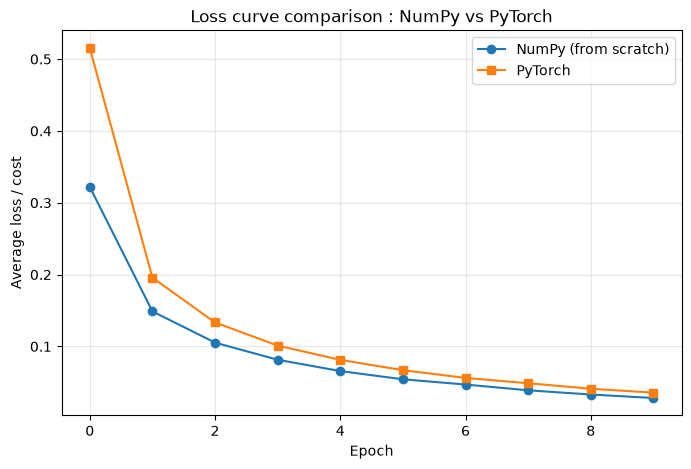

loss_curves.png saved


In [18]:
if HAVE_MATPLOTLIB and HAVE_TORCH:
    plt.figure(figsize=(8, 5))
    plt.plot(cost_history,       label="NumPy (from scratch)", marker="o")
    plt.plot(cost_history_torch, label="PyTorch", marker="s")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss / cost")
    plt.title("Loss curve comparison : NumPy vs PyTorch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("loss_curves.png", dpi=120)
    plt.show()
    print("loss_curves.png saved")

## Depth-independence experiment (no function changes)

We run the exact same code on two architectures: `[784,128,64,10]` and `[784,256,128,64,10]`.
If the functions are written correctly, this **just works** with zero modifications.

In [19]:
for dims in ([784, 128, 64, 10], [784, 256, 128, 64, 10]):
    print("\n--- layer_dims =", dims, "---")
    net2 = NeuralNetwork(dims, learning_rate=0.1)
    net2.initialize()
    net2.train(X_train, Y_train, epochs=3, batch_size=64, shuffle_seed=0)
    acc2 = net2.accuracy(X_test, Y_test)
    print("Test accuracy : {:.2f}%".format(acc2 * 100))


--- layer_dims = [784, 128, 64, 10] ---
Epoch  1  average cost: 0.322016
Epoch  2  average cost: 0.148742
Epoch  3  average cost: 0.105288
Test accuracy : 96.84%

--- layer_dims = [784, 256, 128, 64, 10] ---
Epoch  1  average cost: 0.301066
Epoch  2  average cost: 0.120414
Epoch  3  average cost: 0.082524
Test accuracy : 97.20%


## Initialization experiment: He vs 0.01xrandn vs 1.0xrandn

**Idea:** use the same underlying `randn` numbers and change **only** the scaling, then
train for one epoch and compare the cost.
- **He**: `randn * sqrt(2/n_prev)` — the good one
- **0.01xrandn**: weights near zero (all neurons start identical — hard to learn)
- **1.0xrandn**: unscaled weights (too big — the signals explode)

In [20]:
def initialize_variant(layer_dims, scale_mode, seed=0):
    """Same randn for every variant; only the scaling changes -> fair comparison."""
    np.random.seed(seed)
    parameters = {}
    L = len(layer_dims) - 1
    for l in range(1, L + 1):
        n_prev = layer_dims[l - 1]
        n_l    = layer_dims[l]
        W = np.random.randn(n_l, n_prev)
        if scale_mode == "he":
            W = W * np.sqrt(2.0 / n_prev)
        elif scale_mode == "0.01":
            W = W * 0.01
        elif scale_mode == "1.0":
            pass                    # plain randn
        parameters["W" + str(l)] = W
        parameters["b" + str(l)] = np.zeros((n_l, 1))
    return parameters

for name, mode in [("He (sqrt(2/n))", "he"),
                   ("0.01 * randn", "0.01"),
                   ("1.0 * randn", "1.0")]:
    net_init = NeuralNetwork([784, 128, 64, 10], learning_rate=0.1)
    net_init.parameters = initialize_variant([784, 128, 64, 10], mode, seed=0)
    AL0, _ = model_forward(X_train[:, :64], net_init.parameters)
    start_cost = compute_cost(AL0, Y_train[:, :64])
    hist = net_init.train(X_train, Y_train, epochs=1, batch_size=64, shuffle_seed=0)
    print(">> {:<15} start cost = {:.6f} -> end cost = {:.6f}"
          .format(name, start_cost, hist[-1]))

Epoch  1  average cost: 0.322016
>> He (sqrt(2/n))  start cost = 2.344656 -> end cost = 0.322016
Epoch  1  average cost: 1.269122
>> 0.01 * randn    start cost = 2.302541 -> end cost = 1.269122
Epoch  1  average cost: 2.470886
>> 1.0 * randn     start cost = 23.745409 -> end cost = 2.470886
